## Part 1

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import re
from nltk.corpus import stopwords
import nltk
import Stemmer
from tqdm.notebook import tqdm
nltk.download('stopwords', quiet=True)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer

In [16]:
# Import small test dataset (for checking that the functions work)
url = "https://raw.githubusercontent.com/several27/FakeNewsCorpus/master/news_sample.csv"
df = pd.read_csv(url)

In [17]:
# Define regex patterns to use for tokenization:

# URLs
URL_RE = re.compile(r'https?://\S+|www\.\S+')

# Dates
DATE_RE = re.compile(r'\b\d{1,4}[-/]\d{1,2}[-/]\d{1,4}\b')

# Numbers
NUM_RE = re.compile(r'\b\d+\b')

# Words + special tokens.
TOKENS = re.compile(r'<[^>]+>|[a-zA-Z]+')

# Get stopword list and stemmer.
stop_words = set(stopwords.words('english'))

stemmer = Stemmer.Stemmer('english')

In [18]:
def preprocessing(df):

    # Initialize vocabularies
    vocab_before  = set()
    vocab_no_stop = set()
    vocab_stemmed = set()
    tokenized = []

    # Go through each row (with progress bar)
    for text in tqdm(df["content"], total=len(df), desc="Preprocessing", mininterval=1.0):

        # Make all text lower case
        text = text.lower()

        # Switch out URLs, dates and numbers with special tokens
        text = URL_RE.sub(" <URL> ", text)
        text = DATE_RE.sub(" <DATE> ", text)
        text = NUM_RE.sub(" <NUM> ", text)

        # Make a list of tokens in the text
        tokens_before  = TOKENS.findall(text)

        # Remove stop words
        tokens_no_stop = [t for t in tokens_before if t not in stop_words]

        # Stem the tokens
        tokens_stemmed = stemmer.stemWords(tokens_no_stop)

        # Save the vocabularies at each step
        vocab_before.update(tokens_before)
        vocab_no_stop.update(tokens_no_stop)
        vocab_stemmed.update(tokens_stemmed)
        tokenized.append(tokens_stemmed)

    # Save results in the dataframe
    df["tokenized"] = tokenized

    # Remove unnecessary data from memory
    df.drop(columns=['content'], inplace=True)

    # Print out relevant measures
    for t, vocab in (('After removing stopwords', vocab_no_stop), ('After stemming', vocab_stemmed)):
        print(f'######## {t} ########')
        print(f"Vocabulary size: {len(vocab)}")
        print(f'Reduction rate: {1 - (len(vocab)/len(vocab_before))}\n')

In [19]:
# Process small test set
preprocessing(df)

Preprocessing:   0%|          | 0/250 [00:00<?, ?it/s]

######## After removing stopwords ########
Vocabulary size: 15204
Reduction rate: 0.009575923392612817

######## After stemming ########
Vocabulary size: 9843
Reduction rate: 0.3588039867109635



In [20]:
# Download data from huggingface repositiory (we uploaded the data first).
from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="MikkelPraestegaard/GDS_final_assignment",
    filename="subset_FakeNews.zip",
    repo_type="dataset",
)

In [21]:
# Read in the data
#df1 = pd.read_csv(file_path)

# Remove the single row with NaN in content
#df1 = df1.dropna(subset=['content'])

In [22]:
#preprocessing(df1)

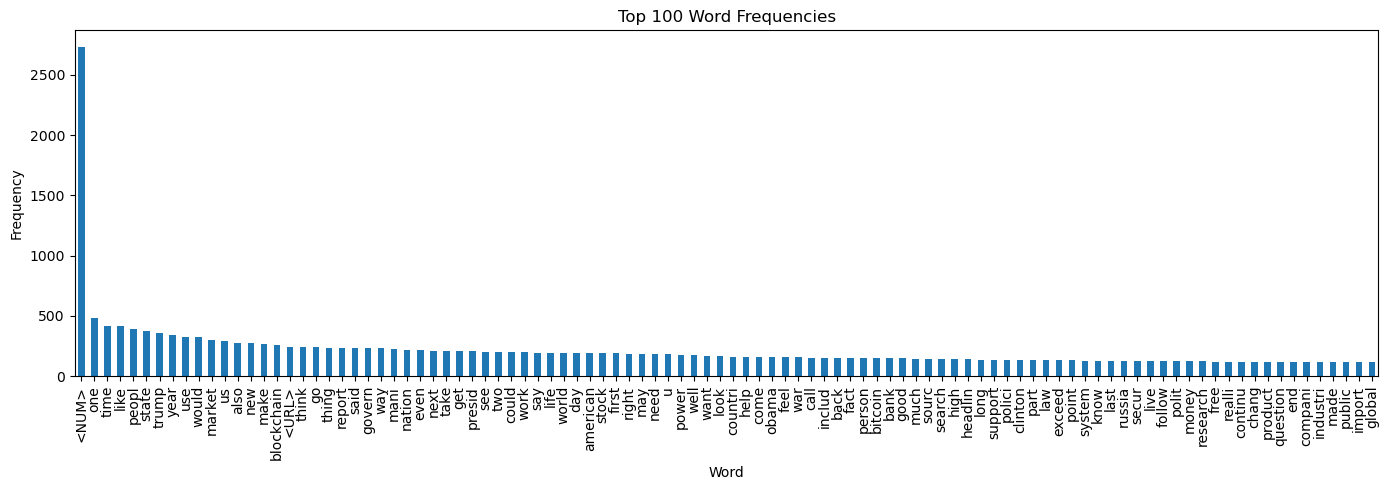

tokenized
<NUM>       2732
one          483
time         418
like         414
peopl        391
            ... 
industri     117
made         116
public       116
import       115
global       115
Name: count, Length: 100, dtype: int64

In [42]:
# Asger
def wordcount(df:pd.DataFrame):
    col = df
    if isinstance(col.iloc[0], str):
        tokens = col.str.split().explode()
    else:
        tokens = col.explode()
    
    tokens = tokens.dropna()
    counts = tokens.value_counts(sort=True)
    return counts

def visualize_top_words(
    df: pd.DataFrame,
    token_col: str,
    top_n: int = 10_000,
    loglog: bool = True
):
    """
    df        : cleaned Pandas DataFrame
    token_col: column containing tokenized text (list of tokens per row)
    top_n    : number of most frequent words to visualize 
    
    If top_n <= 100 there will be put labels on for the x axis.
    """
    label_limit = 100
    # Flatten tokens
    counts = wordcount(df[token_col])
    
    counts = counts.head(top_n)

    # Plot
    plt.figure(figsize=(14, 5))

    if loglog:
        ranks = np.arange(1, len(counts) + 1)
        plt.loglog(ranks, counts.values)
        plt.xlabel("Rank")
        plt.ylabel("Frequency")
        plt.title("Word Frequency (Log-Log Scale)")
    else:
        if top_n <= label_limit:
            counts.plot(kind="bar")
            plt.xlabel("Word")
        else:
            plt.plot(counts.values)
            plt.xlabel("Rank")
        plt.ylabel("Frequency")
        plt.title(f"Top {len(counts)} Word Frequencies")

    plt.tight_layout()
    plt.show()

    return counts

visualize_top_words(df,'tokenized',100,loglog=False)

In [24]:
# Mikkel
def data_split(X, y, train_frac = 0.8, test_frac = 0.1, val_frac = 0.1, stratify=None):
    '''
    Splits the data into a training, testing and validation set. The size fraction of each set
    can be specified.

    Returns a tuple containing features (X) and targets (y) for all sets.
    '''

    # Split the dataset into training and other (test + val) set.
    X_train, X_other, y_train, y_other = train_test_split(X, y, test_size=(1-train_frac), stratify=stratify)

    # Split other into test and val set.
    X_test, X_val, y_test, y_val = train_test_split(X_other, y_other, test_size=(val_frac/(test_frac+val_frac)), stratify=stratify)

    return (X_train, X_test, X_val, y_train, y_test, y_val)

In [ ]:
def prepare_dataset(data):
    
    vocab = wordcount(data['tokenized'])[0:10000].index
    vectorizer = CountVectorizer(vocabulary=vocab, tokenizer=lambda x: x, lowercase=False)
    counts = vectorizer.fit_transform(data['tokenized'])

    return counts



In [ ]:
prepare_dataset(df)

['sometim', 'power', 'christma', 'make', 'wild', 'wonder', 'thing', 'need', 'believ', 'holi', 'triniti', 'believ', 'posit', 'power', 'good', 'other', 'simpl', 'act', 'give', 'without', 'receiv', 'lost', 'mani', 'us', 'day', 'worri', 'money', 'success', 'hold', 'us', 'back', 'give', 'other', 'need', 'one', 'congreg', 'ohio', 'move', 'action', 'power', 'sermon', 'given', 'church', 'christma', 'eve', 'pastor', 'grand', 'lake', 'unit', 'methodist', 'church', 'celina', 'ohio', 'gave', 'emot', 'sermon', 'import', 'understand', 'messag', 'jesus', 'mani', 'religi', 'peopl', 'messag', 'jesus', 'help', 'other', 'make', 'sure', 'peopl', 'suffer', 'get', 'help', 'need', 'enjoy', 'life', 'littl', 'bit', 'sermon', 'realli', 'generos', 'look', 'like', 'live', 'jesus', 'live', 'long', 'time', 'ago', 'act', 'generous', 'fashion', 'time', 'would', 'generous', 'act', 'look', 'like', 'time', 'focus', 'sermon', 'potenc', 'sermon', 'lost', 'congreg', 'move', 'take', 'action', 'sermon', 'end', 'congreg', 'de

/home/mikkel/miniconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


tokenized,<NUM>,one,time,like,peopl,state,trump,year,use,would,...,laundri,laundromat,pair,directv,ch,fio,soe,oo,applaus,yangon
0,2,1,3,3,4,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1,9,1,1,1,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,7,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,6,2,2,3,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
4,11,0,1,1,2,0,5,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,21,5,1,3,7,2,1,2,4,8,...,0,0,0,0,0,0,0,0,0,0
246,1,2,1,0,0,0,1,0,6,0,...,1,1,1,0,0,0,0,0,0,0
247,0,0,0,0,1,1,3,0,0,1,...,0,0,0,0,0,0,0,0,0,0
248,9,1,3,2,1,0,1,3,0,3,...,0,0,0,1,1,1,0,0,1,0
